In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.simulation import simulate_gbm_paths

Matplotlib is building the font cache; this may take a moment.


In [2]:
S0 = 100
r = 0.05
sigma = 0.20
T = 1.0
n_steps = 252
n_paths = 1000

paths = simulate_gbm_paths(
    S0=S0,
    r=r,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_paths,
    seed=42,
)

paths.shape

(1000, 253)

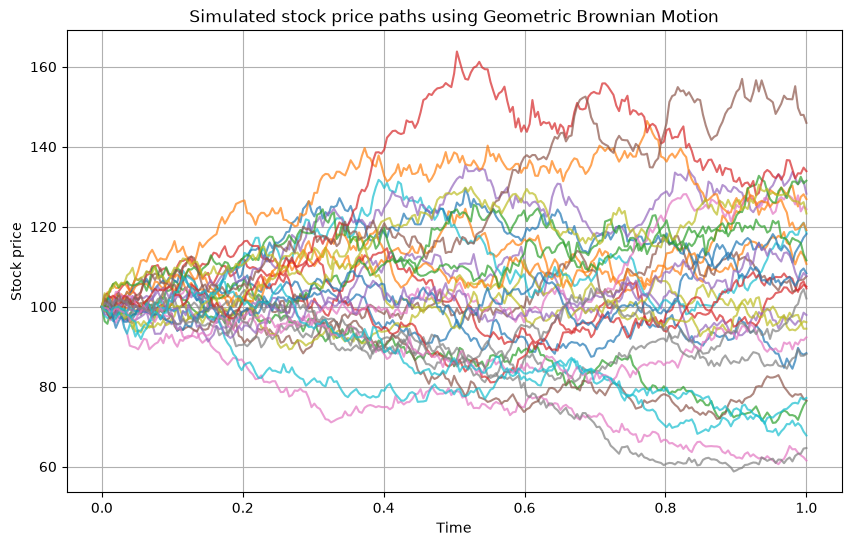

In [3]:
time_grid = np.linspace(0, T, n_steps + 1)

plt.figure(figsize=(10, 6))

for i in range(30):
    plt.plot(time_grid, paths[i], alpha=0.7)

plt.title("Simulated stock price paths using Geometric Brownian Motion")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.grid(True)
plt.show()

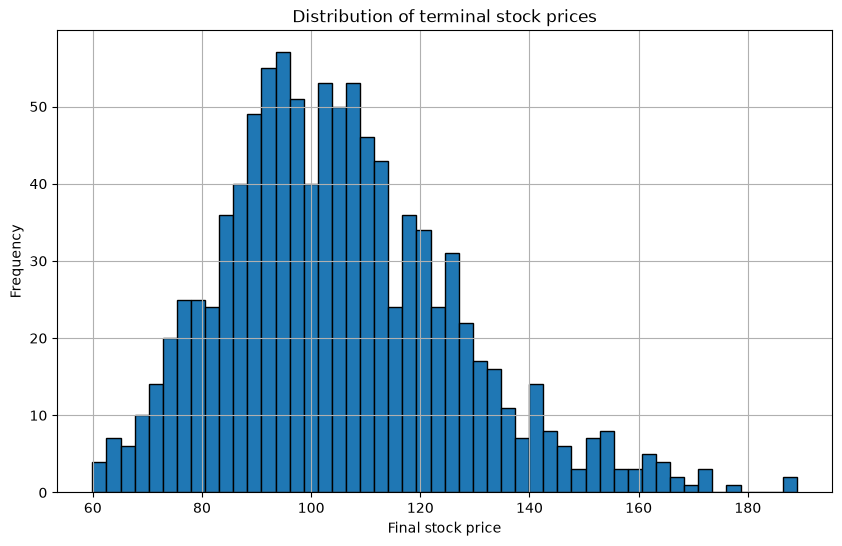

In [4]:
terminal_prices = paths[:, -1]

plt.figure(figsize=(10, 6))
plt.hist(terminal_prices, bins=50, edgecolor="black")

plt.title("Distribution of terminal stock prices")
plt.xlabel("Final stock price")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [5]:
terminal_prices.mean(), terminal_prices.std()

(np.float64(105.14057160831219), np.float64(21.36726961775402))